# Máxima Verosimilitud

### El problema de estimación surge cuando buscamos inferir propiedades generales a partir de una muestra de datos, es decir, construir un modelo que permita generalizar la generación de estos datos.
### Inmediatamente surgen dos problemas: ¿Qué modelo es el adecuado? y ¿Cuáles son los parámetros correctos para éste?

### Podemos clasificar la estimación como paramétrica y no paramétrica. En la primera vamos asumir que los datos vienen de cierto tipo de distribución y nuestro trabajo será estimar los parámetros de esa distribución.

#  Método de Máxima Verosimilitud

### La idea intuitiva detrás de este método es que con una muestra de datos $x_1, \dots, x_n$ podamos estimar el parámetro o parámetros, denotados como $\theta$, de tal modo que la probabilidad de obtener la muestra de datos en tal distribución sea máxima.

### Definición: La función de verosimilitud de $n$ variables aleatorias $X_1, X_2, \dots, X_n$ es definida como la función de distribución conjunta de las $n$ variables aleatorias, es decir, $L_{X_1, X_2, \dots, X_n}(\theta;x_1, x_2, \dots, x_n)$ que es considerada una función de $\theta$.
### En particular, si las variables $X_1, X_2, \dots, X_n$ forman una muestra aleatoria, esto es, son independientes e identicamente distribuidas con densidad $f(x;\theta)$, entonces la función de verosimilitud es: $$L_{X_1, X_2, \dots, X_n}(\theta; x_1, x_2, \dots, x_n)=\prod_{i=1}^n f(x_i;\theta)=f(x_1;\theta)\cdot f(x_2;\theta)\cdot\dots\cdot f(x_n;\theta).$$

### Ejemplo: Supongamos que tenemos una moneda y queremos estimar la probabilidad $p\in(0, 1)$ de que aparezca cara.
### Podemos modelar la distribución de caras y cruces como una distribución Bernoulli que tiene la siguiente función de masa:
### $$f(x)=p^x (1-p)^{1-x}$$ con $x\in \{0,1\}.$

### Para $n$ lanzamientos independientes de la moneda la función de distribución conjunta será:
### \begin{equation} \begin{split} L_{X_1; X_2, \dots, X_n}(x_1, x_2, \dots, x_n; \theta)& =\prod_{i=1}^n f(x_i;\theta)=f(x_1,\theta)\cdot f(x_2;\theta)\cdot\dots\cdot f(x_n;\theta) \\ &= \prod_{i=1}^n p^{x_i}(1-p)^{1-x_i} \end{split}\end{equation}

## Simulación del experimento

In [1]:
from scipy.stats import bernoulli
muestra = bernoulli(0.6).rvs(1000) 

In [2]:
muestra[:10]

array([1, 1, 1, 1, 1, 0, 0, 1, 1, 1], dtype=int64)

### Hemos generado una muestra aleatoria de tamaño 1000. Ahora, a través del método de máxima verosimilitud vamos a tratar de estimar el prámetro $p$ con el cual generamos la distribución.  Para ello, primero construyamos a función de verosimilitud $L(\theta)$

In [3]:
import numpy as np
import sympy 

x,p = sympy.symbols('x, p')
distr = p**x*(1-p)**(1-x) 
L = sympy.prod([distr.subs(x,i) for i in muestra]) 
L

p**595*(1 - p)**405

### Construida la función vemos que es una función de una variable, de la cual vamos a encontrar el valor que maximice esta función.

In [10]:
logL = sympy.expand_log(sympy.log(L))
sol=sympy.solve(sympy.diff(logL,p),p) 
sol

[119/200]

### Así, para este ejemplo, $\widetilde{p}$ =sol es el estimador por máxima verosimilitud para el valor veradero  $p=\frac{1}{2}$.

### Ahora bien, esto se resolvió con sympy, sin embargo, de manera analítica podríamos proceder del siguiente modo:

### La función de verosimilitud es:
### $$ L(\theta)=\prod_{i=1}^n p^{x_i}(1-p)^{1-x_i} $$
### $$=p^{\sum_{i=1}^n x_i}(1-p)^{n-\sum_{i=1}^n x_i}$$

### Podemos proceder como anteriormente tomando el logaritmo y tenemos:

### $$J(p)=log L(p)=\log(p)\sum_{i=1}^n x_i+\log(1-p)\left(n-\sum_{i=1}^n x_i\right)$$

### Ahora, derivando e igualando a cero:
### $$0=\frac{d J(p)}{dp}=\frac{\sum_{i=1}^n x_i}{p}-\frac{n-\sum_{i=1}^n x_i}{1-p}$$

### De donde se obtiene que:
### $$\widehat{p}=\frac{1}{n}\sum_{i=1}^n x_i$$

 ### $\textbf{Ejemplo}$ Estimador de Máxima Verosimilitud para la Exponencial

Consideremos ahora una v.a. Exponencial con media $\theta$, i.e.
$$f(x;\beta)=\frac{1}{\theta}e^{\frac{-x}{\theta}}$$
Dada una muestra $X_1, X_2, \ldots, X_n$, tenemos que 

In [9]:
def verosimilitud_neg(theta, data):
    return len(data) * np.log(theta) + np.sum(data) / theta

In [16]:
import scipy.stats as stats
data = stats.expon.rvs(scale=2, size=1000)

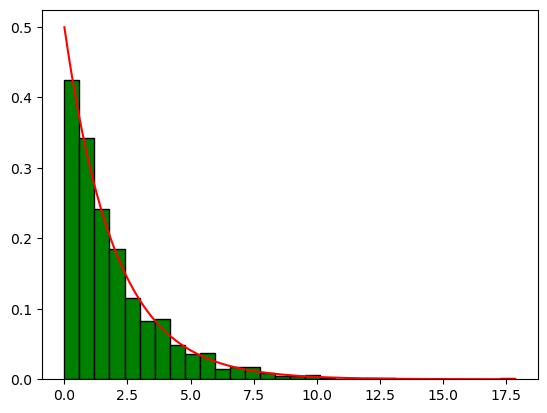

In [26]:
import matplotlib.pyplot as plt

plt.hist(data, bins=30, density=True, color='g', edgecolor='black')
x=np.linspace(min(data), max(data), 1000)
y=stats.expon.pdf(x, scale=2)
plt.plot(x,y, color='r')
plt.show()

In [27]:
from scipy.optimize import minimize
minimize(verosimilitud_neg, x0=[1], args=(data,), method='Nelder-Mead')

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1678.7162662566425
             x: [ 1.971e+00]
           nit: 17
          nfev: 34
 final_simplex: (array([[ 1.971e+00],
                       [ 1.971e+00]]), array([ 1.679e+03,  1.679e+03]))

In [9]:
stats.expon.fit(data)

(0.002121562178213201, 1.9973973141292192)

In [10]:
datos_observados = stats.norm.rvs(loc=0, scale=1, size=1000)
stats.norm.fit(datos_observados)

(0.009560661539821299, 0.9739005158168192)

In [11]:
def calcular_bic_aic(datos, distribucion, parametros):
    n = len(datos)
    k = len(parametros)
    log_likelihood = np.sum(np.log(distribucion.pdf(datos, *parametros)))

    bic = -2 * log_likelihood + k * np.log(n)
    aic = -2 * log_likelihood + 2 * k

    return bic, aic

In [12]:
def ajustar_distribucion(datos, distribuciones):
    mejor_distribucion = None
    mejores_parametros = None
    mejor_bic = np.inf

    for distribucion in distribuciones:
        parametros = distribucion.fit(datos)
        bic, aic = calcular_bic_aic(datos, distribucion, parametros)
        
        if bic < mejor_bic:
            mejor_distribucion = distribucion
            mejores_parametros = parametros
            mejor_bic = bic

    return mejor_distribucion, mejores_parametros, mejor_bic

In [14]:
from scipy.stats import norm, expon, gamma, lognorm, beta, chi2

distribuciones = [norm, expon, gamma, lognorm, beta, chi2]

datos = stats.norm.rvs(loc=0, scale=1, size=1000) 

mejor_distribucion, mejores_parametros, mejor_bic = ajustar_distribucion(datos, distribuciones)
print(mejor_distribucion.name, mejores_parametros, mejor_bic)

norm (0.005955982806234477, 1.0289363763740227) 2908.743825767345


In [15]:
import seaborn as sns
diam=sns.load_dataset('diamonds')

In [16]:
diam.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [17]:
diam.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [19]:
diampremium=diam[diam['cut']=='Premium']

In [20]:
len(diampremium)

13791

In [21]:
depth_premium=diampremium['depth']

In [22]:
depth_premium.isna().sum()

0

<Axes: xlabel='depth'>

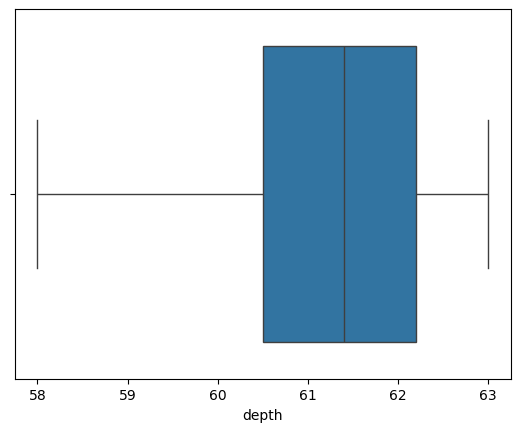

In [23]:
sns.boxplot(x=depth_premium)

In [24]:
import Ajuste
Ajuste.comparar_distribuciones(depth_premium, ordenar='aic')

---------------------------------------------------
       Distribuciones seleccionadas                
---------------------------------------------------
          distribucion      tipo  dominio_inf  dominio_sup
0               cauchy  continua         -inf          inf
1          crystalball  continua         -inf          inf
2               dgamma  continua         -inf          inf
3             dweibull  continua         -inf          inf
4            exponnorm  continua         -inf          inf
5           genextreme  continua         -inf          inf
6        genhyperbolic  continua         -inf          inf
7          genlogistic  continua         -inf          inf
8              gennorm  continua         -inf          inf
9             gumbel_l  continua         -inf          inf
10            gumbel_r  continua         -inf          inf
11           hypsecant  continua         -inf          inf
12           jf_skew_t  continua         -inf          inf
13           johns

,distribucion,log_likelihood,aic,bic,n_parametros,parametros
0,kappa4,-19120.338428,38248.676857,38278.803943,4,"{'h': 0.8246275329831766, 'k': 1.2610405288385..."
1,genextreme,-20246.681683,40499.363365,40521.958679,3,"{'c': 0.6487162535360371, 'loc': 61.0697504282..."
2,skewnorm,-20314.223277,40634.446553,40657.041868,3,"{'a': -14.826340364864755, 'loc': 62.906855100..."
3,pearson3,-20460.742932,40927.485863,40950.081178,3,"{'skew': -1.3281826297367294, 'loc': 61.264667..."
4,genhyperbolic,-20468.087127,40946.174255,40983.833112,5,"{'p': 2.5235169026381357, 'a': 4.1370343007975..."
5,norminvgauss,-20647.895833,41303.791665,41333.918751,4,"{'a': 55.4190823116472, 'b': -55.1964804943752..."
6,johnsonsu,-20711.137037,41430.274075,41460.401161,4,"{'a': 9.300846053676278, 'b': 2.32806707617967..."
7,loggamma,-20782.151079,41570.302158,41592.897472,3,"{'c': 0.5897637393378141, 'loc': 62.2935864771..."
8,gumbel_l,-20812.749741,41629.499483,41644.563026,2,"{'loc': 61.80700978096889, 'scale': 0.92680055..."
9,powernorm,-20858.856993,41723.713987,41746.309301,3,"{'c': 5846.620351497686, 'loc': 74.90116048640..."
